In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# 랜덤 초기값 세팅
np.random.seed(42)
torch.manual_seed(42)


In [2]:
data = {
    'temperature': [10, 15, 22, 25, 28, 35, 38],
    'humidity':    [30, 40, 50, 55, 60, 70, 80],
    'y':           [ 0,  0,  1,  1,  1,  0,  0]
}
df = pd.DataFrame(data)
df

,temperature,humidity,y
0,10,30,0
1,15,40,0
2,22,50,1
3,25,55,1
4,28,60,1
5,35,70,0
6,38,80,0


In [3]:
# 원본 입력데이터를 넘파이 (n,2)배열로 바꿈
X_raw = df[['temperature', 'humidity']].to_numpy(dtype=np.float32)
X_raw

array([[10., 30.],
       [15., 40.],
       [22., 50.],
       [25., 55.],
       [28., 60.],
       [35., 70.],
       [38., 80.]], dtype=float32)

In [4]:
# 정답 컬럼 y
y = df['y'].to_numpy(dtype=np.float32).reshape(-1, 1)
y

array([[0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.]], dtype=float32)

In [ ]:
# 입력값 정규화 하기위해 컬럼별 평균, 표준편차 구함. 차원 그대로 유지
X_mean = X_raw.mean(axis=0, keepdims=True)
X_std = X_raw.std(axis=0, keepdims=True)

print(f'X_mean={X_mean}, X_std={X_std}')

X_mean=[[24.714285 55.      ]], X_std=[[ 9.345959 15.811388]]


In [7]:
# 정규화
X_norm = (X_raw - X_mean) / X_std
X_norm

array([[-1.5744008 , -1.5811388 ],
       [-1.0394102 , -0.9486833 ],
       [-0.29042336, -0.31622776],
       [ 0.03057098,  0.        ],
       [ 0.35156533,  0.31622776],
       [ 1.1005522 ,  0.9486833 ],
       [ 1.4215466 ,  1.5811388 ]], dtype=float32)

In [8]:
# X_norm을 Tensor로 변환
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
X_tensor

tensor([[-1.5744, -1.5811],
        [-1.0394, -0.9487],
        [-0.2904, -0.3162],
        [ 0.0306,  0.0000],
        [ 0.3516,  0.3162],
        [ 1.1006,  0.9487],
        [ 1.4215,  1.5811]])

In [9]:
# 정답도 tensor로 변환
y_tensor = torch.tensor(y, dtype=torch.float32)
y_tensor

tensor([[0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.]])

In [10]:
# 정규화된 컬럼 (n,1)배열로 꺼내기
X1_norm = X_tensor[:, [0]]
X2_norm = X_tensor[:, [1]]
X1_norm, X2_norm

(tensor([[-1.5744],
         [-1.0394],
         [-0.2904],
         [ 0.0306],
         [ 0.3516],
         [ 1.1006],
         [ 1.4215]]),
 tensor([[-1.5811],
         [-0.9487],
         [-0.3162],
         [ 0.0000],
         [ 0.3162],
         [ 0.9487],
         [ 1.5811]]))

In [17]:
# np.random.randn()은 평균 0, 표준편차 1 의 정규분포난수를 만듬.
# 난수에 0.1을 곱하는 이유는 처음부터 가중치가 너무 크면 sigmoid출력이 0 또는 1에 너무 가까이 붙어버려 
# 학습이 잘 진행되지 않을 수 있기 때문.

# 히든뉴런 1 가중치

a11 = torch.tensor(np.random.randn() * 0.1, dtype=torch.float32, requires_grad=True) # 온도
a12 = torch.tensor(np.random.randn() * 0.1, dtype=torch.float32, requires_grad=True) # 습도
b1 = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)
# 히든뉴런 2 가중치
a21 = torch.tensor(np.random.randn() * 0.1, dtype=torch.float32, requires_grad=True)
a22 = torch.tensor(np.random.randn() * 0.1, dtype=torch.float32, requires_grad=True)
b2 = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)
# 출력층
a31 = torch.tensor(np.random.randn() * 0.1, dtype=torch.float32, requires_grad=True)
a32 = torch.tensor(np.random.randn() * 0.1, dtype=torch.float32, requires_grad=True)
b3 = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)

In [11]:
def mlp_forward_textbook_style_torch(
        X1_norm, X2_norm, a11, a12, b1, a21, a22, b2, a31, a32, b3
):
    H_hidden_1 = a11 * X1_norm + a12 * X2_norm + b1
    z_hidden_1 = torch.sigmoid(H_hidden_1)

    H_hidden_2 = a21 * X1_norm + a22 * X2_norm + b2
    z_hidden_2 = torch.sigmoid(H_hidden_2)

    H_output = a31 * z_hidden_1 + a32 * z_hidden_2 + b3
    z_output = torch.sigmoid(H_output)

    return H_hidden_1, z_hidden_1, H_hidden_2, z_hidden_2, H_output, z_output


In [13]:
def bce_cost_torch(y, z_output):
    epsilon = 1e-7
    # z_output  범위를 epsilon으로 살짝 잘라 log(0)막기
    z_output = torch.clamp(z_output, epsilon, 1 - epsilon)
    cost = -torch.mean(
        y * torch.log(z_output) + (1 - y) * torch.log(1 - z_output)
    )
    return cost

In [18]:
# 순전파 실행해서 shape, cost 확인
H_hidden_1 = a11 * X1_norm + a12 * X2_norm + b1
z_hidden_1 = torch.sigmoid(H_hidden_1)

H_hidden_2 = a21 * X1_norm + a22 * X2_norm + b2
z_hidden_2 = torch.sigmoid(H_hidden_2)

H_output = a31 * z_hidden_1 + a32 * z_hidden_2 + b3
z_output = torch.sigmoid(H_output)

cost = bce_cost_torch(y_tensor, z_output)
z_output.shape, cost.item()

(torch.Size([7, 1]), 0.6901158094406128)

In [ ]:
cost.backward()
# gradient 확인
a11.grad, a12.grad, b1.grad, a31.grad, b3.grad

(tensor(0.0002),
 tensor(3.3147e-06),
 tensor(-0.0006),
 tensor(0.0294),
 tensor(0.0598))

In [20]:
# 학습 시작전 gradient 초기화
params = [a11, a12, b1, a21, a22, b2, a31, a32, b3]
for p in params:
    if p.grad is not None:
        p.grad.zero_()

In [21]:
learning_rate = 0.5
epochs = 3000
cost_history = []

In [22]:
training_log = []

for epoch in range(epochs):
    # 히든레이어
    H_hidden_1 = a11 * X1_norm + a12 * X2_norm + b1
    z_hidden_1 = torch.sigmoid(H_hidden_1)

    H_hidden_2 = a21 * X1_norm + a22 * X2_norm + b2
    z_hidden_2 = torch.sigmoid(H_hidden_2)

    # 출력층
    H_output = a31 * z_hidden_1 + a32 * z_hidden_2 + b3
    z_output = torch.sigmoid(H_output)

    # cost 계산
    cost = bce_cost_torch(y_tensor, z_output)
    cost_history.append(cost.item())

    cost.backward()

    # 대표 epoch 과정 기록
    if epoch % 500 == 0:
        training_log.append({
            'epoch': epoch,
            'cost': cost.item(),
            'a11': a11.item(),
            'b1': b1.item(),
            'a31': a31.item(),
            'b3': b3.item(),
            'a11_grad': a11.grad.item() if a11.grad is not None else float('nan'),
            'b1_grad': b1.grad.item() if b1.grad is not None else float('nan'),
            'a31_grad': a31.grad.item() if a31.grad is not None else float('nan'),
            'b3_grad': b3.grad.item() if b3.grad is not None else float('nan'),
        })
        print(f'epoch={epoch:4d}, cost={cost.item():.6f}')

    # 파라미터 업데이트
    with torch.no_grad():
        for p in params:
            if p.grad is not None: # 안전장치. grad가 있을 때만 업데이트
                p -= learning_rate * p.grad
        
        # 다음 epoch를 위한 gradient 초기화
        for p in params:
            if p.grad is not None:
                p.grad.zero_()


epoch=   0, cost=0.690116
epoch= 500, cost=0.682791
epoch=1000, cost=0.682486
epoch=1500, cost=0.662689
epoch=2000, cost=0.095177
epoch=2500, cost=0.029589


In [24]:
training_log_df = pd.DataFrame(training_log)
training_log_df

,epoch,cost,a11,b1,a31,b3,a11_grad,b1_grad,a31_grad,b3_grad
0,0,0.690116,0.157921,0.000000,-0.046342,0.000000,0.000152,-0.000621,0.029361,0.059816
1,500,0.682791,0.099323,-0.014997,-0.028964,-0.164790,0.000079,0.000023,-0.000297,-0.000095
2,1000,0.682486,0.099455,-0.014403,0.029204,-0.122001,-0.000044,-0.000023,-0.000157,-0.000238
3,1500,0.662689,0.096488,-0.008214,0.005265,0.004014,0.000060,-0.000006,0.000464,-0.002630
4,2000,0.095177,2.541680,-3.273899,-5.519231,2.685960,-0.006258,0.008967,0.017791,-0.007985
5,2500,0.029589,3.333037,-4.354381,-7.950275,3.823293,-0.001713,0.002253,0.005760,-0.002777


In [25]:
# 학습후 cost 숫자 확인
cost_history[0], cost_history[-1], 'cost decreased:', cost_history[-1] < cost_history[0]

(0.6901158094406128, 0.01702534593641758, 'cost decreased:', True)

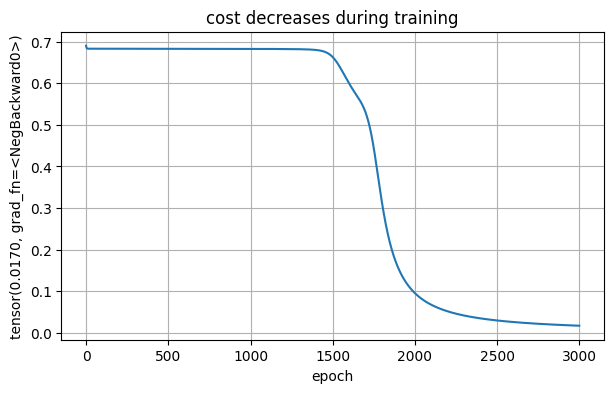

In [26]:
plt.figure(figsize=(7,4))
plt.plot(cost_history)
plt.xlabel('epoch')
plt.ylabel(cost)
plt.title('cost decreases during training')
plt.grid(True)

In [27]:
# 학습 끝난 파라미터로 최종 예측
with torch.no_grad():
    H_hidden_1 = a11 * X1_norm + a12 * X2_norm + b1
    z_hidden_1 = torch.sigmoid(H_hidden_1)

    H_hidden_2 = a21 * X1_norm + a22 * X2_norm + b2
    z_hidden_2 = torch.sigmoid(H_hidden_2)

    H_output = a31 * z_hidden_1 + a32 * z_hidden_2 + b3
    z_output = torch.sigmoid(H_output)

    pred = (z_output >= 0.5).float()
    accuracy = (pred == y_tensor).float().mean()

In [28]:
result_df = df[['temperature', 'humidity', 'y']].copy()
# 계산추적 끊고 numpy배열로 바꾸기
z_output_np = z_output.detach().numpy()
# (n,1)배열에서 1차원 배열로 바꾸기
z_output_1d = z_output_np.reshape(-1)
# 소수점 4자리 반올림
result_df['z_output'] = z_output_1d.round(4)

pred_np = pred.detach().numpy()
pred_1d = pred_np.reshape(-1)
result_df['pred'] = pred_1d.astype(int)
print('accuracy:', accuracy.item())
result_df

accuracy: 1.0


,temperature,humidity,y,z_output,pred
0,10,30,0,0.0096,0
1,15,40,0,0.0163,0
2,22,50,1,0.9767,1
3,25,55,1,0.9854,1
4,28,60,1,0.9732,1
5,35,70,0,0.0180,0
6,38,80,0,0.0094,0


In [29]:
final_params_df = pd.DataFrame({
    'parameter': ['a11', 'a12', 'b1', 'a21', 'a22', 'b2', 'a31', 'a32', 'b3'],
    'value': [
        a11.item(), a12.item(), b1.item(),
        a21.item(), a22.item(), b2.item(),
        a31.item(), a32.item(), b3.item(),
    ]
})
final_params_df

,parameter,value
0,a11,3.643602
1,a12,3.422137
2,b1,-4.758941
3,a21,-4.549940
4,a22,-3.090142
5,b2,-4.922268
6,a31,-9.039706
7,a32,-9.000286
8,b3,4.352614
